Precision: 0.0
Recall: 0.0

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.92      0.93        38
           1       0.00      0.00      0.00         2

    accuracy                           0.88        40
   macro avg       0.47      0.46      0.47        40
weighted avg       0.90      0.88      0.89        40



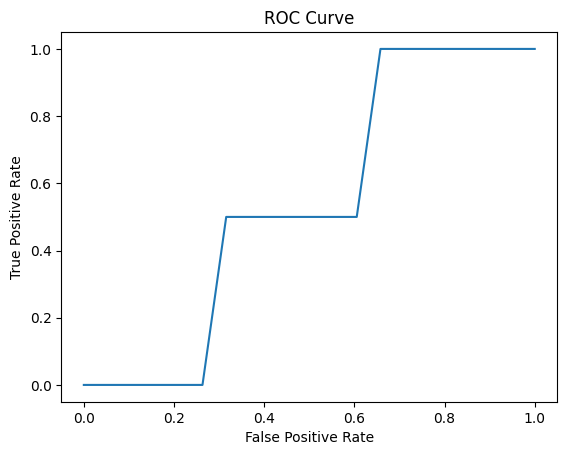

AUC Score: 0.5394736842105263


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    classification_report
)

# Create dataset (imbalanced)
np.random.seed(42)

X = np.random.rand(200, 4)

# Imbalanced target (90% 0, 10% 1)
y = np.array([0]*180 + [1]*20)

# 2️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3️⃣ Model (with imbalance handling)
model = RandomForestClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

# 4️⃣ Prediction
pred = model.predict(X_test)

# 5️⃣ Precision & Recall
precision = precision_score(y_test, pred)
recall = recall_score(y_test, pred)

print("Precision:", precision)
print("Recall:", recall)

# 6️⃣ Full report
print("\nClassification Report:\n")
print(classification_report(y_test, pred))

# 7️⃣ ROC Curve
probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# 8️⃣ AUC Score
auc = roc_auc_score(y_test, probs)
print("AUC Score:", auc)